# Lab | Text Generation from Shakespeare's Sonnet

In [1]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
### YOUR CODE HERE
# Figure out how to import regularizers
from tensorflow.keras import regularizers
import tensorflow.keras.utils as ku 
import numpy as np 

In [8]:
tokenizer = Tokenizer()
    
data = """
from fairest creatures we desire increase
that thereby beauty's rose might never die
but as the riper should by time decease
his tender heir might bear his memory
but thou contracted to thine own bright eyes
feed'st thy light's flame with self-substantial fuel
making a famine where abundance lies
thyself thy foe to thy sweet self too cruel
thou that art now the world's fresh ornament
and only herald to the gaudy spring
within thine own bud buriest thy content
and tender churl mak'st waste in niggarding
pity the world or else this glutton be
to eat the world's due by the grave and thee

when forty winters shall besiege thy brow
and dig deep trenches in thy beauty's field
thy youth's proud livery so gazed on now
will be a tattered weed of small worth held
then being asked where all thy beauty lies
where all the treasure of thy lusty days
to say within thine own deep sunken eyes
were an all-eating shame and thriftless praise
how much more praise deserved thy beauty's use
if thou couldst answer this fair child of mine
shall sum my count and make my old excuse
proving his beauty by succession thine
this were to be new made when thou art old
and see thy blood warm when thou feel'st it cold
"""
    

corpus = data.lower().split("\n")

tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1

# create input sequences using list of tokens
input_sequences = []
for line in corpus:
	token_list = tokenizer.texts_to_sequences([line])[0]
	for i in range(1, len(token_list)):
		n_gram_sequence = token_list[:i+1]
		input_sequences.append(n_gram_sequence)


# pad sequences 
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# create predictors and label
predictors, label = input_sequences[:,:-1],input_sequences[:,-1]

label = ku.to_categorical(label, num_classes=total_words)

In [ ]:
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))         # maps each word to a 100-dimensional vector.
model.add(LSTM(150, return_sequences=True))     # 150 LSTM units; return_sequences=True allows stacking another LSTM on top.
model.add(Dropout(0.2))     # randomly drops 20% of connections during training to reduce overfitting
model.add(LSTM(100))        # second LSTM layer with 100 units.
model.add(Dense(50, activation='relu', kernel_regularizer=regularizers.l2(0.01)))   # adds L2 penalty (sum of squared weights) to the dense layer's weights to discourage large weights.
model.add(Dense(total_words, activation='softmax'))
# Pick an optimizer
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
 history = model.fit(predictors, label, epochs=100, verbose=1)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.0155 - loss: 5.6513   
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0515 - loss: 5.5749
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0515 - loss: 5.4891
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0515 - loss: 5.3958
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0515 - loss: 5.3105
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0515 - loss: 5.2507
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0515 - loss: 5.2043
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0515 - loss: 5.1655
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0515 - loss: 5.1473
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0515 - loss: 5.0809
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0515 - loss: 5.0368
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0567 -

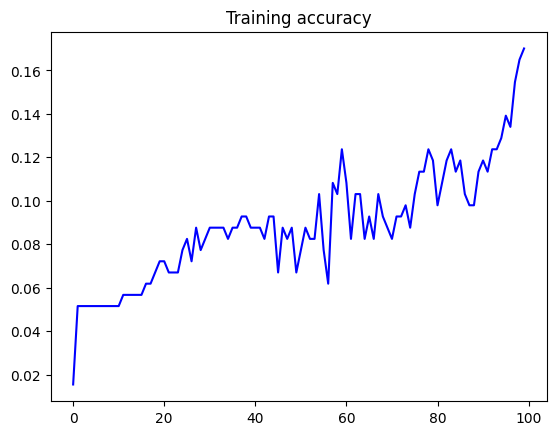

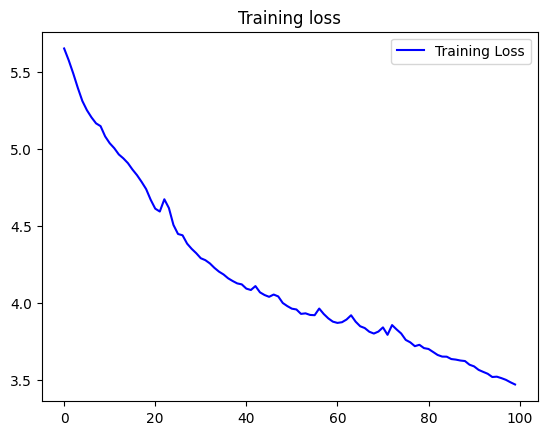

In [11]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.title('Training accuracy')

plt.figure()

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.title('Training loss')
plt.legend()

plt.show()

In [13]:
seed_text = "Help me Obi Wan Kenobi, you're my only hope"
next_words = 100

for _ in range(next_words):
    # Convert seed text to sequence of integers
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    # Pad to the required input length (max_sequence_len-1)
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    # Predict probabilities for next word
    predicted_probs = model.predict(token_list, verbose=0)
    # Get the index of the highest probability word
    predicted = np.argmax(predicted_probs, axis=-1)[0]
    # Find the word corresponding to that index
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted:
            output_word = word
            break
    # Append the predicted word to the seed text
    seed_text += " " + output_word

print(seed_text)

Help me Obi Wan Kenobi, you're my only hope thine thine thy when spring old cruel thee cold cruel thee thee cruel thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee thee
